# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Load Data

In [3]:
df = pd.read_csv('../data/df_working_clean.csv')

# Set Plot Style

In [4]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

df.head()

,Days for shipment (scheduled),Late_delivery_risk,Category Name,Latitude,Longitude,Order Item Discount Rate,Order Item Quantity,Sales,Order Region,Product Name,Product Price,order_month,order_dayofweek,order_quarter,order_year,order_hour,Type_CASH,Type_DEBIT,Type_PAYMENT,Type_TRANSFER,Customer Segment_Consumer,Customer Segment_Corporate,Customer Segment_Home Office,Department Name_Apparel,Department Name_Fan Shop,Department Name_Fitness,Department Name_Footwear,Department Name_Golf,Department Name_Outdoors,Market_Africa,Market_Europe,Market_LATAM,Market_Pacific Asia,Market_USCA,Shipping Mode_First Class,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,4,0,4,35.776661,-81.362625,0.20,1,299.980011,3,11,299.980011,1,3,1,2015,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1
1,4,0,28,41.832722,-87.980484,0.03,1,199.990005,12,51,199.990005,1,3,1,2015,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1
2,4,0,29,41.832722,-87.980484,0.09,5,250.000000,12,41,50.000000,1,3,1,2015,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1
3,4,0,21,41.832722,-87.980484,0.17,1,129.990005,12,38,129.990005,1,3,1,2015,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1
4,4,1,18,29.520010,-98.637413,0.20,4,199.919998,12,49,49.980000,1,3,1,2015,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1


# Target Variable Distribution

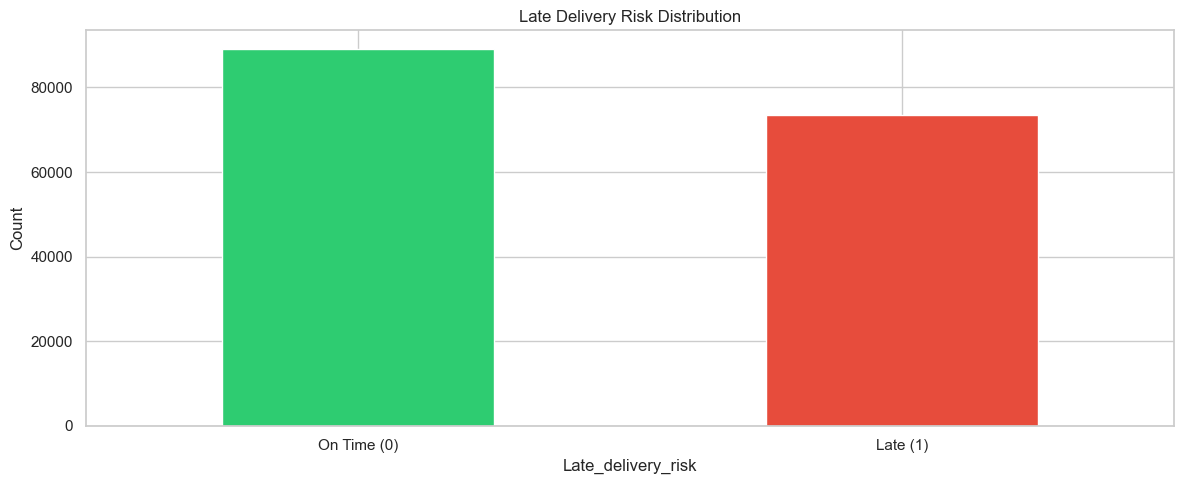

In [5]:
fig, ax = plt.subplots()
df['Late_delivery_risk'].value_counts().plot(
    kind='bar', 
    color=['#2ecc71', '#e74c3c'], 
    ax=ax
)
ax.set_title('Late Delivery Risk Distribution')
ax.set_xticklabels(['On Time (0)', 'Late (1)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation with target variable

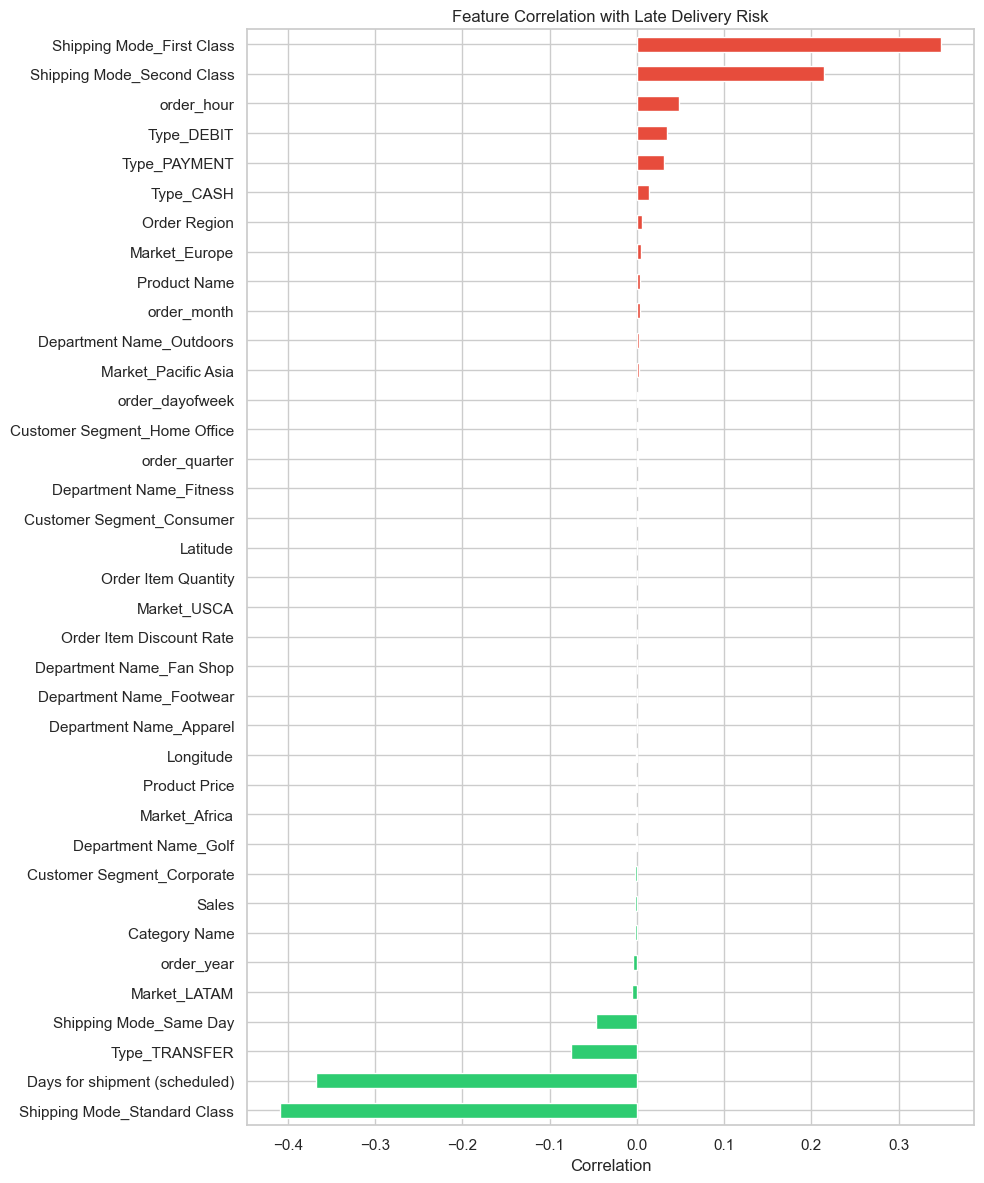

Top 10 correlated features:
Shipping Mode_Standard Class     0.408637
Days for shipment (scheduled)    0.367916
Shipping Mode_First Class        0.348605
Shipping Mode_Second Class       0.214883
Type_TRANSFER                    0.075882
order_hour                       0.048443
Shipping Mode_Same Day           0.046724
Type_DEBIT                       0.034788
Type_PAYMENT                     0.030546
Type_CASH                        0.013334
Name: Late_delivery_risk, dtype: float64


In [6]:
correlations = df.corr()['Late_delivery_risk'].drop('Late_delivery_risk').sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
correlations.plot(kind='barh', ax=ax, color=[
    '#e74c3c' if x > 0 else '#2ecc71' for x in correlations
])
ax.set_title('Feature Correlation with Late Delivery Risk')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

print("Top 10 correlated features:")
print(correlations.abs().sort_values(ascending=False).head(10))

## Late Delivery Rate by Shipping Mode

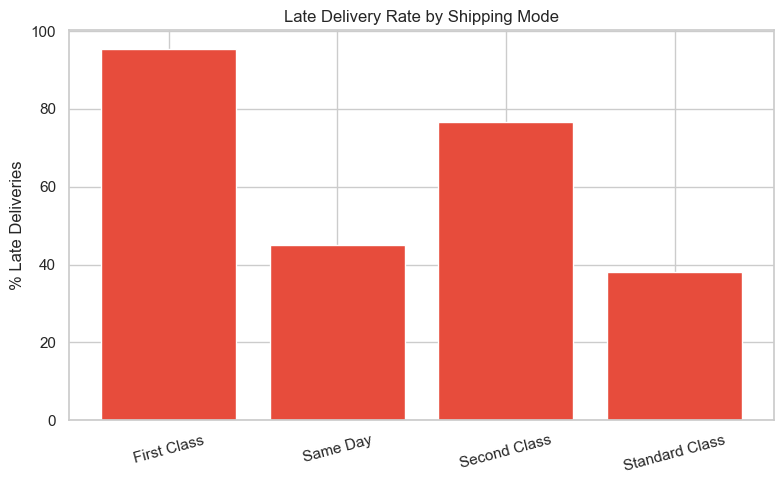

In [9]:
plt.figure(figsize=(8, 5))

shipping_cols = ['Shipping Mode_First Class', 'Shipping Mode_Same Day', 
                 'Shipping Mode_Second Class', 'Shipping Mode_Standard Class']

late_by_shipping = {col.replace('Shipping Mode_', ''): 
                    df[df[col]==1]['Late_delivery_risk'].mean() * 100 
                    for col in shipping_cols}

plt.bar(late_by_shipping.keys(), late_by_shipping.values(), color='#e74c3c')
plt.title('Late Delivery Rate by Shipping Mode')
plt.ylabel('% Late Deliveries')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Late Delivery Rate by Scheduled Shipping Days

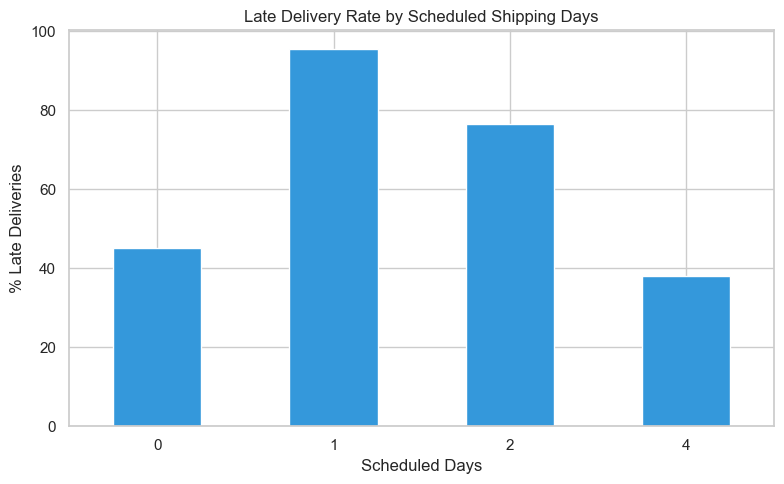

In [10]:
plt.figure(figsize=(8, 5))

df.groupby('Days for shipment (scheduled)')['Late_delivery_risk'].mean().mul(100).plot(
    kind='bar', color='#3498db'
)

plt.title('Late Delivery Rate by Scheduled Shipping Days')
plt.ylabel('% Late Deliveries')
plt.xlabel('Scheduled Days')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()